## Проект. Исследование стартапов

## 1. Цель и задачи 

**Цель:** Иисследовать структуру и динамику финансирования стартапов, чтобы определить наиболее перспективные сегменты рынка и рекомендовать наиболее подходящий тип финансирования для инвестиций.


**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных:
   - Проверить  названия столбцов в датасетах;
   - Проверка и корректировка типов данных;
   - Обработать полные дубликаты в данных и пропуски;
   - Заполнить пропуски в значениях в столбце `mid_funding_at`
3. Инжиниринг признаков:
    - Группы по срокам финансирования;
    - Выделение средних и нишевых сегментов рынка;
4. Работа с выбросами и анализ:
    - Анализ и помечение выбросов в каждом из сегментов;
    - Определение границ рассматриваемого периода, отброс аномалии;
    - Анализ типов финансирования по объёму и популярности;
5. Анализ динамики:
    - Динамика предоставления финансирования по годам;
    - Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов;
    - Годовая динамика доли возвращённых средств по типам финансирования;
6. Итоговый вывод и рекомендации.


## 2. Данные

Данные состоят из двух датасетов:

- `cb_investments.csv` - Содержит информацию о компаниях и состоявшемся финансировании;
- `cb_returns.csv` - Содержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов.

### 2.1. Описание датасета `cb_investments.csv`

- `name` — название компании;
- `homepage_url` — ссылка на сайт компании;
- `category_list` — категории, в которых работает компания. Указываются через |;
- `market` — основной рынок или отрасль компании;
- `funding_total_usd` — общий объём привлечённых инвестиций в долларах США;
- `status` — текущий статус компании, например, operating, closed и так далее;
- `country_code` — код страны, например USA;
- `state_code` — код штата или региона, например CA;
- `region` — регион, например SF Bay Area;
- `city` — город, в котором расположена компания;
- `funding_rounds` — общее число раундов финансирования;
- `participants` — число участников в раундах финансирования;
- `founded_at` — дата основания компании;
- `founded_month` — месяц основания в формате YYYY-MM;
- `founded_quarter` — квартал основания в формате YYYY-QN;
- `founded_year` — год основания;
- `first_funding_at` — дата первого финансирования;
- `mid_funding_at` — дата среднего по времени раунда финансирования;
- `last_funding_at` — дата последнего финансирования;
- `seed` — сумма инвестиций на посевной стадии;
- `venture` — сумма венчурных инвестиций;
- `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг;
- `undisclosed` — сумма финансирования нераскрытого типа;
- `convertible_note` — сумма инвестиций через конвертируемые займы;
- `debt_financing` — сумма долгового финансирования;
- `angel` — сумма инвестиций от бизнес-ангелов;
- `grant` — сумма полученных грантов;
- `private_equity` — сумма инвестиций в виде прямых (частных) вложений;
- `post_ipo_equity` — сумма финансирования после IPO;
- `post_ipo_debt` — сумма долгового финансирования после IPO;
- `secondary_market` — сумма сделок на вторичном рынке;
- `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг;
- `round_A — round_H` — сумма инвестиций в соответствующем раунде.

### 2.2. Описание датасета `cb_returns.csv`

- `year` — год возврата средств;
- `seed` — сумма возвратов от посевных инвестиций;
- `venture` — сумма возвратов от венчурных инвестиций;
- `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу;
- `undisclosed` — сумма возвратов нераскрытого типа;
- `convertible_note` — сумма возвратов через конвертируемые займы;
- `debt_financing` — сумма возвратов от долгового финансирования;
- `angel` — сумма возвратов бизнес-ангелам;
- `grant` — сумма возвратов по грантам;
- `private_equity` — сумма возвратов прямых (частных) вложений;
- `post_ipo_equity` — сумма возвратов от IPO;
- `post_ipo_debt` — сумма возвратов от долгового IPO;
- `secondary_market` — сумма возвратов от сделок на вторичном рынке;
- `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

## 3. Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---



## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `cb_investments.csv` и `cb_returns.csv`. Будем использовать `pandas` и библиотеки визуализации данных `matplotlib` и `seaborn`, а также `phik` для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `investments_df` и `returns_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Выгружаем данные в переменные investments_df и returns_df
investments_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
returns_df = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

Познакомимся с данными датасета `investments_df` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
investments_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Выводим информацию о датафрейме
investments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  str    
 1   homepage_url          45989 non-null  str    
 2   category_list         45477 non-null  str    
 3    market               45477 non-null  str    
 4    funding_total_usd    49438 non-null  str    
 5   status                48124 non-null  str    
 6   country_code          44165 non-null  str    
 7   state_code            30161 non-null  str    
 8   region                44165 non-null  str    
 9   city                  43322 non-null  str    
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38554 no

Датасет `investments_df` содержит 40 столбцов и 54294 строк, которые содержат информацию о компаниях и состоявшемся финансировании.

После первичного анализа данных можно сделать следующие выводы:
- В данных присутствуют пропуски в нескольких текстовых и категориальных признаках, а также в датах основания компаний. Типы данных в большинстве столбцов соответствуют содержимому.
- Названия столбцов оформлены единообразно, изменение их имен не требуется.
- Типы данных: В таблице представлены два типа данных — 24 столбца с плавающей точкой (`float64`) и 16 столбцов с текстовыми или категориальными значениями (`str`).
- Особенности типов данных. Столбец `funding_total_usd` (общая сумма финансирования) имеет тип данных `str` (строка). Для проведения математических расчетов, построения графиков и поиска среднего/медианы этот столбец обязательно нужно будет очистить от лишних символов (например, знаков доллара, запятых) и привести к числовому типу (`float или int`).
- Даты основания (`founded_at, founded_month, founded_quarter, founded_year`) их необходимо привести к соответствующему временному типу: специальный формат `datetime` с помощью функции `pd.to_datetime()`.
- Кроме того, необходимо проверить наличие дубликатов и обработать пропущенные значения.

Теперь познакомимся с данными датасета `returns_df` - также выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [5]:
# Выводим первые строки датафрейма на экран
returns_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
# Выводим информацию о датафрейме
returns_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет `returns_df` содержит 15 строк и 14 столбцов, в них хранятся информация об объёмах возвратов по годам и типам финансирования в миллионах долларов.

- Названия столбцов оформлены в едином стиле `snake case`.
- В датасете представленны два типа данных — 13 столбцов с плавающей точкой (`float64`) и 1 столбец с целочисленным типом `int64`
- Столбец `year` нужно сделать индексом всего датасета
- Явные пропуски отсутствуют, однако необходимо проверить данные на наличие значений-индикаторов (например, нулей или специальных обозначений), которые могут означать отсутствие информации.
Настало время следующего этапа — предобработки данных.

---


## 2. Предобработка данных

### 2.1. Проверяем названия, или метки, столбцов датафрейма


Проверим оба датафрейма — судя по описанию, названия столбцов уже в `snake_case`, но стоит явно вывести `df.columns`, чтобы убедиться, что нет пробелов, разного регистра или скрытых опечаток.

In [7]:
# Выводим названия столбцов датафрейма investments_df
investments_df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='str')

У некоторых столбцов есть лишние пробелы по краям названия (перед и после слова). Это нужно исправить сразу, иначе дальше при обращении к этим столбцам будет выдавать `KeyError`, ведь на самом деле столбец называется `' market '` (с пробелами), а не `'market'`.

In [8]:
# Уберём лишние пробелы по краям названий столбцов investments_df
investments_df.columns = investments_df.columns.str.strip()

# Проверим результат
investments_df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='str')

Лишние пробелыв названих столбцов убраны. Это делает код более читаемым и уменьшает вероятность ошибок при обращении к столбцам.

In [9]:
# Выводим названия столбцов датафрейма returns_df
returns_df.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='str')

В датасете `returns_df` — всё чисто, пробелов и опечаток не видно, названия аккуратные, в snake_case, дополнительной обработки не требуется.

### 2.2. Проверка и корректировка типов данных

In [10]:
# Смотрим типы данных всех столбцов
investments_df.dtypes 

name                        str
homepage_url                str
category_list               str
market                      str
funding_total_usd           str
status                      str
country_code                str
state_code                  str
region                      str
city                        str
funding_rounds          float64
participants            float64
founded_at                  str
founded_month               str
founded_quarter             str
founded_year            float64
first_funding_at            str
mid_funding_at              str
last_funding_at             str
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_

In [11]:
# Уберём запятые-разделители и переведём в число
investments_df['funding_total_usd'] = (
    investments_df['funding_total_usd']
    .str.replace(',', '', regex=False)
    .replace(' - ', None) # убираем прочерки
)

# Используем to_numeric с параметром errors='coerce'
investments_df['funding_total_usd'] = pd.to_numeric(
    investments_df['funding_total_usd'], 
    errors='coerce'
)

# Проверим результат
investments_df['funding_total_usd'].dtype


dtype('float64')

Из столбца удалены разделители разрядов, после чего значения успешно преобразованы к числовому типу. Теперь столбец можно использовать для вычислений и статистического анализа.

In [12]:
# Список столбцов с датами
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

# Переведём каждый столбец в формат datetime
for column in date_columns:
    investments_df[column] = pd.to_datetime(investments_df[column], errors='coerce')

# Проверим результат
investments_df[date_columns].dtypes

founded_at          datetime64[us]
first_funding_at    datetime64[us]
mid_funding_at      datetime64[us]
last_funding_at     datetime64[us]
dtype: object

- Столбцы с некорректнымии типами данных были исправлены на соответствующие типы.

In [13]:
# Сделаем столбец year индексом датафрейма returns_df
returns_df = returns_df.set_index('year')

# Проверим результат
returns_df.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0



### 2.3. Обработка полных дубликатов и пропусков в данных


In [14]:
# Проверим полные дубликаты в investments_df
investments_df.duplicated().sum()

np.int64(4855)

In [15]:
# Дубликаты есть — удалим их
investments_df = investments_df.drop_duplicates()

In [16]:
# Проверим полные дубликаты в returns_df
returns_df.duplicated().sum()

np.int64(0)

In [17]:
# Удалим строки без данных о финансировании
investments_df = investments_df.dropna(subset=['funding_total_usd'])

# Проверим, сколько строк осталось
investments_df.shape[0]

40907

In [18]:
# Уберем со столбца пробелы
investments_df['market'] = investments_df['market'].str.strip()
# Заполняем пропуски в market заглушкой 'unknown'
investments_df['market'] = investments_df['market'].fillna('unknown')

- В ходе анализа было выявлено 4855 полных дубликатов в датафрейме `investments_df`. Все повторы были успешно удалены, поскольку не несут новой информации и могут исказить результаты анализа и  для обеспечения корректности дальнейших расчетов.В датафрейме `returns_df` полные дубликаты строк отсутствуют.
- Пропуски в столбце `market` (2503, около 6%) заполнены заглушкой `'unknown'`. Это позволяет не терять сами компании (у них есть данные о финансировании, датах и других признаках, полезные для остальных разделов анализа), при этом на этапе сегментации рынка `'unknown'` будет обработан как отдельная маленькая группа, не искажая классификацию остальных сегментов.

### 2.4. Заполнение пропуски в значениях в столбце mid_funding_at

In [19]:
# Заполним пропуски в mid_funding_at серединой между first_funding_at и last_funding_at
mask = investments_df['mid_funding_at'].isna()

investments_df.loc[mask, 'mid_funding_at'] = (
    investments_df.loc[mask, 'first_funding_at'] + 
    (investments_df.loc[mask, 'last_funding_at'] - investments_df.loc[mask, 'first_funding_at']) / 2
)

# Проверим, сколько пропусков осталось
investments_df['mid_funding_at'].isna().sum()

np.int64(0)

Для заполнения пропусков использована середина интервала между первым и последним раундом финансирования. Такой способ позволяет получить наиболее реалистичную оценку даты среднего раунда и не смещает данные к началу или концу периода.

In [20]:
# Посчитаем, какой процент строк был отброшен от исходного количества
original_count = 54294  # исходное количество строк из первого investments_df.info()

# Текущее количество строк после удаления дубликатов и строк без funding_total_usd
final_count = investments_df.shape[0]

# Считаем процент отброшенных данных
dropped_percent = (original_count - final_count) / original_count * 100

print(f'Исходные строки: {original_count}')
print(f'Осталось строк: {final_count}')
print(f'Отброшено: {dropped_percent:.1f}% данных')

Исходные строки: 54294
Осталось строк: 40907
Отброшено: 24.7% данных


In [21]:
# Проверим оставшиеся пропуски по всем столбцам
investments_df.isna().sum().sort_values(ascending=False)

state_code              15288
participants            13576
founded_month            8772
founded_quarter          8772
founded_at               8706
founded_year             8706
city                     4505
country_code             3819
region                   3819
category_list            2503
homepage_url             2314
status                   1105
name                        1
market                      0
funding_total_usd           0
funding_rounds              0
first_funding_at            0
mid_funding_at              0
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_A                     0
round_B   

-  Пропуски в `mid_funding_at` полностью заполнены — рассчитаны как середина интервала между `first_funding_at` и `last_funding_at`, пропусков не осталось. 
-  В результате предобработки (удаление дубликатов и строк без данных о финансировании) из исходных 54294 строк осталось 40907 — то есть отброшено около 24.7 % данных. Это существенная, но не критичная доля: удалённые строки не содержали ключевой информации (суммы финансирования), поэтому не могли быть использованы для решения задач проекта. Оставшихся данных достаточно для дальнейшего исследовательского анализа, хотя стоит учитывать, что почти четверть исходного датасета была неинформативной или дублирующейся, что говорит о не самом высоком исходном качестве данных.
-  Наибольшее количество пропусков сосредоточено в текстовых столбцах, содержащих сведения о местоположении компаний, участниках финансирования и датах основания. При этом ключевые для исследования признаки (funding_total_usd, funding_rounds) практически не содержат пропусков, поэтому качество данных позволяет продолжить анализ.
-  На этапе предобработки были очищены названия столбцов, исправлены типы данных, удалены полные дубликаты, удалены записи без информации о финансировании, заполнены пропуски в `mid_funding_at`.

Предобработка завершена. Названия столбцов приведены к единому стилю, типы данных исправлены, обработаны пропуски и удалены дубликаты. Объём удалённых данных невелик и не оказывает существенного влияния на репрезентативность выборки. Полученные данные готовы для дальнейшего анализа и построения новых признаков.
После проведенной обработки датасет готов к созданию новых признаков и исследовательскому анализу.

## 3. Инжиниринг признаков

 ### 3.1. Группы компаний по срокам финансирования



Для дальнейшего анализа разделим компании по длительности периода финансирования.
Нужно разделить компании на 3 группы:

- Единичное финансирование — был только 1 раунд (funding_rounds == 1)
- До года — между первым и последним раундом прошло ≤ 1 года
- Более года — между первым и последним раундом прошло > 1 года

In [22]:
# Посчитаем разницу между last_funding_at и first_funding_at в днях
funding_duration = (investments_df['last_funding_at'] - investments_df['first_funding_at']).dt.days

# Определяем продолжительность периода финансирования каждой компании
# и присваиваем ей одну из трех категорий
def get_funding_group(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif (row['last_funding_at'] - row['first_funding_at']).days <= 365:
        return 'До года'
    else:
        return 'Более года'

# Применим функцию к каждой строке
investments_df['funding_group'] = investments_df.apply(get_funding_group, axis=1)

# Проверим результат
investments_df['funding_group'].value_counts()

funding_group
Единичное финансирование    24113
Более года                  12293
До года                      4501
Name: count, dtype: int64

Для каждой компании сформирован новый признак, отражающий продолжительность периода финансирования. Он позволит сравнить компании по длительности привлечения инвестиций.

 Строим график по количеству компаний (в процентах)

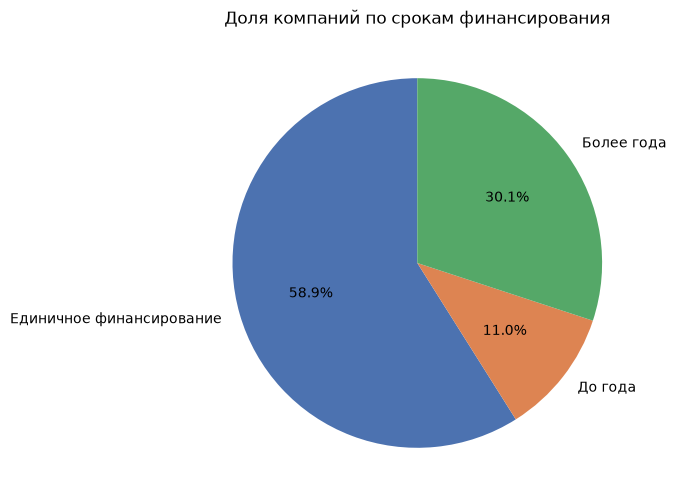

In [23]:
# Зададим фиксированный порядок категорий и цвета для обоих графиков
category_order = ['Единичное финансирование', 'До года', 'Более года']
colors = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(6, 6))

group_counts = investments_df['funding_group'].value_counts(normalize=True)

group_counts.reindex(category_order).plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
)

plt.ylabel('')
plt.title('Доля компаний по срокам финансирования')
plt.show()

Наибольшую долю составляют компании с единичным финансированием. Это говорит о том, что значительная часть стартапов привлекала инвестиции лишь один раз. Компаний с длительным периодом финансирования существенно меньше.

Строим график по объёму инвестиций (в процентах)

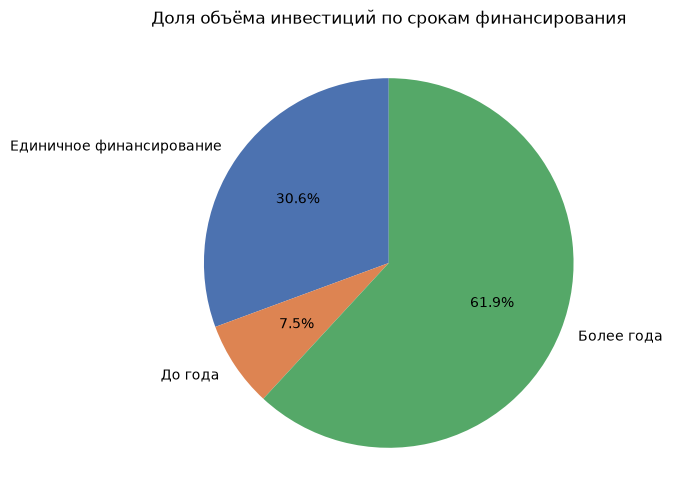

In [24]:
plt.figure(figsize=(6, 6))

group_funding = investments_df.groupby('funding_group')['funding_total_usd'].sum()
group_funding_share = group_funding / group_funding.sum()

group_funding_share.reindex(category_order).plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
)

plt.ylabel('')
plt.title('Доля объёма инвестиций по срокам финансирования')
plt.show()

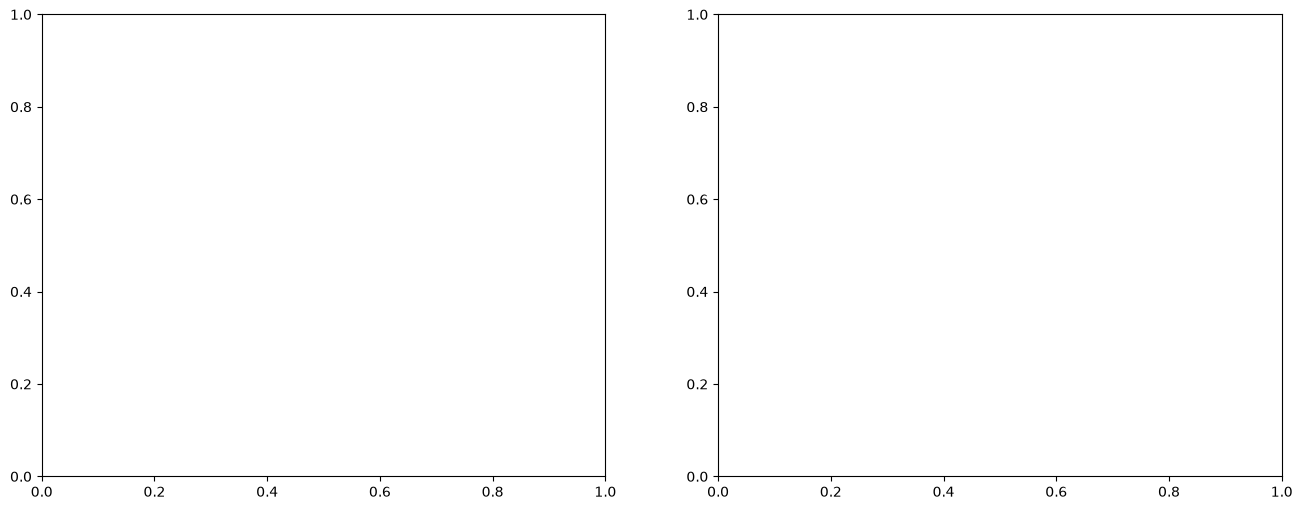

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# axes[0] — по количеству, axes[1] — по объёму

Несмотря на то что компаний с единичным финансированием больше, основной объём привлечённых средств может приходиться на компании, которые проходили несколько раундов финансирования. Это свидетельствует о более высокой инвестиционной активности подобных стартапов.

### 3.2. Сегментация рынка (массовые/средние/нишевые)

In [25]:
# Посчитаем сколько раз встречается каждый сегмент в столбце market
market_counts = investments_df['market'].value_counts()

# Убираем 'unknown' — это заглушка для пропуска, а не настоящий рынок,
# и не должна участвовать в сегментации/классификации
market_counts = market_counts.drop('unknown', errors='ignore')

market_counts

market
Software                 4812
Biotechnology            3590
Mobile                   2344
E-Commerce               1866
Curated Web              1693
                         ... 
Employment                  1
Real Estate Investors       1
Business Productivity       1
Musicians                   1
Gold                        1
Name: count, Length: 394, dtype: int64

Рассчитали, как часто в датасете встречается каждый из сегментов. Самые часто встречающиеся это массовые сегменты как: Software, Biotechnology,  Mobile и несколько похожих. Самые редко встречаюшиея это нишевые: Musicians, Location Based Services, Gold и еще несколько похожих

In [26]:
# Определяем, к какой из трёх категорий относится каждый сегмент
market_counts = investments_df['market'].value_counts()

#  Пишем простую функцию для классификации полученных чисел
def get_segment_by_count(count):
    if count > 120:
        return 'массовый'
    elif 35 <= count <= 120:
        return 'средний'
    else:
        return 'нишевый'

# 3. Применяем функцию к частотам и смотрим итоговое распределение сегментов
segment_category=market_counts.apply(get_segment_by_count)
segment_category_counts=segment_category.value_counts()
segment_category_counts

count
нишевый     289
средний      57
массовый     49
Name: count, dtype: int64

Определили что к каждой категории относятся: нишевого сегмента - 289, среднего - 57, массового - 49. 

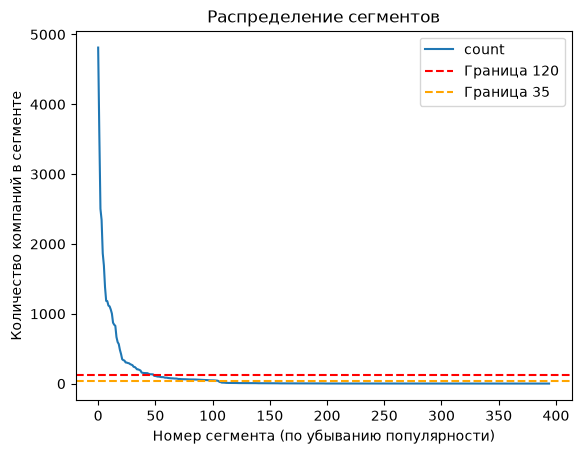

In [27]:
# Сбросим индекс с названий сегментов на простую нумерацию (0, 1, 2, ...)
market_counts_reset = market_counts.reset_index(drop=True)
market_counts_reset.plot(kind='line', title='Распределение сегментов')
plt.xlabel('Номер сегмента (по убыванию популярности)')
plt.ylabel('Количество компаний в сегменте')
# Линия на уровне 120 (граница между массовыми и средними)
plt.axhline(y=120, color='red', linestyle='--', label='Граница 120')

# Линия на уровне 35 (граница между средними и нишевыми)
plt.axhline(y=35, color='orange', linestyle='--', label='Граница 35')

plt.legend()
plt.show()

Большинство рыночных сегментов относится к нишевым, тогда как массовых сегментов значительно меньше. Это говорит о высокой специализации рынка стартапов и большом количестве относительно небольших направлений деятельности.

Оставляем в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

In [28]:
# напишем небольшую функцию для замены 
def replace_market(market_value):
    category = segment_category.get(market_value)
    if category == 'средний': # там, где категория "средний" — заменим market на 'mid'
        return 'mid'
    elif category == 'нишевый': # там, где категория "нишевый" — заменим market на 'niche'
        return 'niche'
    else:
        return market_value  # оставляем массовые как есть

investments_df['market'] = investments_df['market'].apply(replace_market)

In [29]:
# выводим результат
investments_df['market'].value_counts()

market
Software                4812
mid                     3841
Biotechnology           3590
unknown                 2503
Mobile                  2344
E-Commerce              1866
Curated Web             1693
Enterprise Software     1381
Health Care             1185
Clean Technology        1180
Games                   1117
Advertising             1107
Hardware + Software     1062
Social Media            1003
Health and Wellness      873
Education                844
niche                    830
Finance                  828
Analytics                667
Manufacturing            596
Security                 567
Semiconductors           484
Web Hosting              424
Consulting               349
Hospitality              336
Travel                   330
Fashion                  303
News                     301
Messaging                295
Search                   291
Real Estate              279
SaaS                     272
Music                    264
Internet                 241
Technol

После анализа распределения сегментов рынка все сегменты были разделены на три группы:

• массовые (более 120 компаний);

• средние (от 35 до 120 компаний);

• нишевые (менее 35 компаний).

Названия средних и нишевых сегментов были заменены соответственно на значения `mid и niche`, поскольку дальнейший анализ проводится не по отдельным небольшим сегментам, а по объединённым группам. Это позволит уменьшить количество редких категорий и сделать результаты анализа более устойчивыми.

На данном этапе компании были разделены по продолжительности финансирования и масштабу рыночного сегмента. Большинство компаний относится к нишевым направлениям, однако дальнейший анализ будет проводиться по укрупнённым категориям, что позволит повысить наглядность результатов и снизить влияние высокой детализации данных.

## 4. Работа с выбросами и анализ

### 4.1. Анализируем и помечаем выбросы в каждом из сегментов

In [30]:
# Смотрим базовую статистику по столбцу funding_total_usd:
investments_df['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Распределение `funding_total_usd` сильно асимметрично: типичная компания (медиана) привлекла около 2 млн долларов, тогда как среднее значение (16 млн) искажено единичными компаниями с экстремально большим финансированием — вплоть до 30 млрд долларов, что в тысячи раз превышает типичные суммы. Также обращает на себя внимание минимальное значение в 1 доллар — крайне маловероятная сумма для реального раунда финансирования.Значение максимума значительно превышает верхний квартиль, что говорит о наличии крайне крупных компаний с очень большими объемами финансирования. Такие наблюдения могут являться выбросами и требуют отдельной проверки.

Чтобы визуально увидеть, насколько сильно распределение "растянуто" экстремально большими значениями, построим гистограмму:

(array([4.0834e+04, 5.3000e+01, 7.0000e+00, 5.0000e+00, 2.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 2.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([1.00000000e+00, 6.01590061e+08, 1.20318012e+09, 1.80477018e+09,
        2.40636024e+09, 3.00795030e+09, 3.60954036e+09, 4.21113042e+09,
        4.81272048e+09, 5.41431054e+09, 6.01590060e+09, 6.61749066e+09,
        7.21908072e+09, 7.82067078e+09, 8.42226084e+09, 9.02385090e+09,
        9.62544096e+09, 1.0227

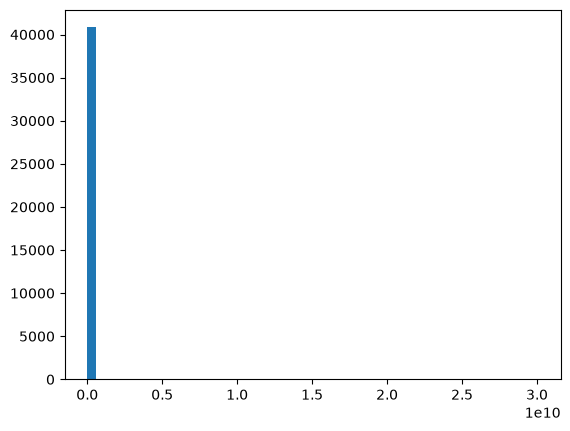

In [31]:
# Строим обычную гистограмму funding_total_usd без преобразований
plt.hist(investments_df['funding_total_usd'], bins=50)

Из-за сильной правосторонней асимметрии большая часть наблюдений сосредоточена около нуля, поэтому распределение плохо различимо. Для более информативной визуализации применим логарифмическое преобразование.

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 1.200e+01, 2.000e+00, 5.000e+00,
        8.000e+00, 6.000e+00, 5.700e+01, 4.100e+01, 5.500e+01, 1.040e+02,
        8.000e+01, 4.940e+02, 1.061e+03, 1.202e+03, 1.205e+03, 1.489e+03,
        1.516e+03, 2.018e+03, 1.943e+03, 2.695e+03, 3.067e+03, 3.080e+03,
        3.483e+03, 3.224e+03, 2.942e+03, 2.924e+03, 2.437e+03, 2.056e+03,
        1.515e+03, 9.810e+02, 6.160e+02, 2.670e+02, 1.630e+02, 8.400e+01,
        3.700e+01, 1.900e+01, 7.000e+00, 2.000e+00, 3.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([ 0.        ,  0.20956541,  0.41913083,  0.62869624,  0.83826165,
         1.04782707,  1.25739248,  1.46695789,  1.6765233 ,  1.88608872,
         2.09565413,  2.30521954,  2.51478496,  2.72435037,  2.93391578,
         3.1434812 ,  3.35304661,  3.56261202,  3.77217744,  3.98174285,
         4.19130826,  4.40087368,  4.61043909,  4.8200045 ,  5.02956991,
         5.

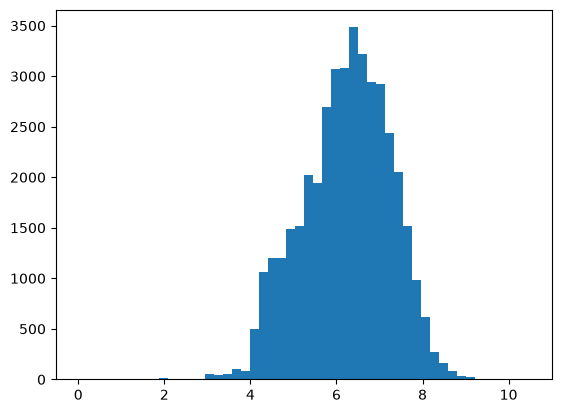

In [32]:
# log10, то есть каждое число — это степень десятки
log_funding = np.log10(investments_df['funding_total_usd'])

plt.hist(log_funding, bins=50)

Типичный размер общего финансирования для одной компании — примерно от `$1 000` до `$100 000 000`, с пиком около `$1 000 000`. Суммы значительно ниже `$1000` или выше` $100 000 000` — редкие, потенциально аномальные значения.Это подтверждает, что экстремально большие значения оказывают сильное влияние на исходное распределение. Однако для поиска выбросов будет использоваться исходный столбец `funding_total_usd`, так как именно реальные значения интересуют заказчика.

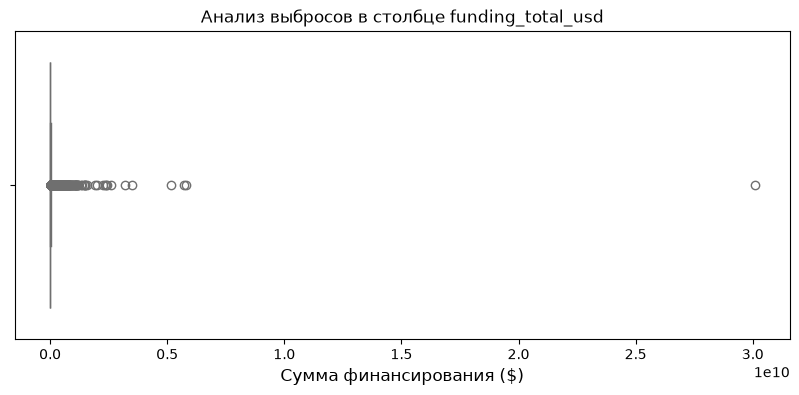

In [33]:
# Настройка размера графика
plt.figure(figsize=(10, 4))

# Строим горизонтальный боксплот (для вертикального замените x= на y=)
sns.boxplot(x=investments_df['funding_total_usd'], color='skyblue')

# Настраиваем заголовки
plt.title('Анализ выбросов в столбце funding_total_usd')
plt.xlabel('Сумма финансирования ($)', fontsize=12)

plt.show()

Диаграмма размаха показывает, что распределение общего объёма финансирования сильно скошено вправо. Большинство компаний привлекло относительно небольшие суммы, тогда как небольшая группа компаний получила финансирование, значительно превышающее типичный уровень. Наличие длинного правого хвоста свидетельствует о большом количестве потенциальных выбросов

In [34]:
# Рассчитываем границы выбросов методом межквартильного размаха отдельно для каждого сегмента рынка
q1 = investments_df.groupby('market')['funding_total_usd'].quantile(0.25)

q3 = investments_df.groupby('market')['funding_total_usd'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr

upper = q3 + 1.5 * iqr

In [35]:
display(pd.DataFrame({
    'Q1': q1,
    'Q3': q3,
    'IQR': iqr,
    'lower': lower,
    'upper': upper
}))

,Q1,Q3,IQR,lower,upper
market,,,,,
Advertising,500000.00,11144998.00,10644998.00,-1.546750e+07,2.711250e+07
Analytics,500000.00,11079181.00,10579181.00,-1.536877e+07,2.694795e+07
Apps,100000.00,2169575.00,2069575.00,-3.004362e+06,5.273938e+06
Automotive,265032.50,10000000.00,9734967.50,-1.433742e+07,2.460245e+07
Big Data,300000.00,7000000.00,6700000.00,-9.750000e+06,1.705000e+07
Biotechnology,1500000.00,22031670.50,20531670.50,-2.929751e+07,5.282918e+07
Clean Technology,1500000.00,28196619.50,26696619.50,-3.854493e+07,6.824155e+07
Cloud Computing,585305.00,10000000.00,9414695.00,-1.353674e+07,2.412204e+07
Consulting,125000.00,5330000.00,5205000.00,-7.682500e+06,1.313750e+07


Для каждого сегмента рынка рассчитаны первый и третий квартили, межквартильный размах (IQR), а также верхняя и нижняя границы выбросов. Нижние границы для большинства сегментов оказались отрицательными, что объясняется большим разбросом данных и формулой расчета IQR. Поскольку объем финансирования не может принимать отрицательные значения, при поиске выбросов основное внимание будет уделено превышению верхней границы.

In [36]:
# Для каждой компании определим верхнюю границу выброса (upper), соответствующую её сегменту рынка
investments_df['upper'] = investments_df['market'].map(upper)

In [37]:
# Для каждой компании определим нижнюю границу выброса (lower), соответствующую её сегменту рынка
investments_df['lower'] = investments_df['market'].map(lower)

# Создаём бинарный признак is_outlier — является ли значение funding_total_usd, выбросом относительно границ 
investments_df['is_outlier'] = (
    (investments_df['funding_total_usd'] < investments_df['lower']) |
    (investments_df['funding_total_usd'] > investments_df['upper'])
)

Для каждой компании определено, относится ли объём её финансирования к типичным значениям или является аномальным относительно компаний того же сегмента рынка.

In [38]:
# Посчитаем долю выбросов в процентах
investments_df['is_outlier'].value_counts(normalize=True) * 100

is_outlier
False    87.180678
True     12.819322
Name: proportion, dtype: float64

In [39]:
# Посмотрим на первые строки среди помеченных как выбросы 
investments_df[investments_df['is_outlier']].head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_C,round_D,round_E,round_F,round_G,round_H,funding_group,upper,lower,is_outlier
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,11821079.25,-6796582.75,True
5,Xavier University,http://www.xavier.edu/,NaN,unknown,19000000.0,operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,5418268.00,-3163780.00,True
6,Tulane University,http://tulane.edu/,|Education|,Education,12000000.0,operating,USA,LA,New Orleans,New Orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,До года,11821079.25,-6796582.75,True
8,"Virginia Commonwealth University, Richmond",http://www.vcu.edu/,NaN,unknown,6000000.0,operating,USA,VA,Richmond,Richmond,...,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,5418268.00,-3163780.00,True
10,VideoSurf,http://www.videosurf.com,|Hardware + Software|,Hardware + Software,28000000.0,acquired,USA,CA,SF Bay Area,San Mateo,...,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,26792376.25,-14871425.75,True


In [40]:
# посмотрим сумму
investments_df['is_outlier'].sum()

np.int64(5244)

Методом IQR было выявлено 5244 компаний с аномально высоким объемом финансирования, что составляет около 12,8 % выборки. Эти наблюдения будут исключены на следующем этапе анализа.

In [41]:
# Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование.
outliers_share = (
    investments_df
    .groupby('market')['is_outlier']
    .mean()
    .sort_values(ascending=False)
)

outliers_share.head(10)

market
Real Estate        0.172043
Entertainment      0.166667
Consulting         0.166189
Search             0.164948
Cloud Computing    0.164474
Photography        0.161765
SaaS               0.161765
Technology         0.159664
Video              0.159574
niche              0.159036
Name: is_outlier, dtype: float64

Наибольшая доля компаний с аномальным объемом финансирования наблюдается в сегментах Real Estate (17,2%), Entertainment (16,7%) и Consulting (16,7%). Это говорит о том, что именно в этих направлениях чаще встречаются компании, привлекшие значительно больше инвестиций по сравнению с типичным уровнем своего сегмента рынка.

### 4.2. Определение границ рассматриваемого периода, отброс аномалии

Создадим новый датасет без компаний с аномально большим финансированием.

In [42]:
# Создаём новый датафрейм investments_clean без компаний-выбросов
investments_clean = investments_df[
    ~investments_df['is_outlier']
].copy()

Из анализа исключены компании с аномально высоким объемом финансирования, определенные методом `IQR`. Это позволяет снизить влияние экстремальных значений на дальнейшие расчеты и получить более репрезентативные результаты.

Посчитаем, сколько компаний приходится на каждый год по `mid_funding_at`.

In [43]:
# Проверим, сколько компаний приходится на каждый год по mid_funding_at
investments_clean['mid_funding_at'].dt.year.value_counts().sort_index()

mid_funding_at
1011       1
1921       1
1960       2
1979       1
1982       3
1983       1
1984       2
1985       3
1987       2
1989       1
1990       1
1992       4
1993       1
1994       4
1995       4
1996       3
1997       4
1998       9
1999      28
2000      65
2001      37
2002      48
2003      63
2004      96
2005     697
2006    1165
2007    1600
2008    1984
2009    2618
2010    3467
2011    4311
2012    5533
2013    7821
2014    6083
Name: count, dtype: int64

Анализ показывает, что данные за 2014 год являются неполными: часть компаний ещё не завершила процесс финансирования, поэтому показатели за этот год могут быть занижены. Это следует учитывать при интерпретации результатов.

In [44]:
# Считаем СУММУ funding_rounds по годам 
rounds_sum_by_year = investments_clean.groupby(investments_clean['mid_funding_at'].dt.year)['funding_rounds'].sum()
# Оставляем только те годы, где суммарно было 50 и более раундов
good_years = rounds_sum_by_year[rounds_sum_by_year >= 50].index

investments_clean = investments_clean[investments_clean['mid_funding_at'].dt.year.isin(good_years)]

In [45]:
#  смотрим объем итоговой таблицы
investments_clean.shape

(35588, 44)

Дополнительно оставлены только компании, чьё среднее время финансирования (mid_funding_at) приходится на годы, в которые суммарно было зафиксировано 50 и более раундов финансирования по всем компаниям. Это исключает годы с недостаточным количеством данных для надёжного анализа. Сформирована очищенная выборка (35 588 строк, 44 столбца), которая будет использоваться в дальнейшем анализе.

### 4.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег

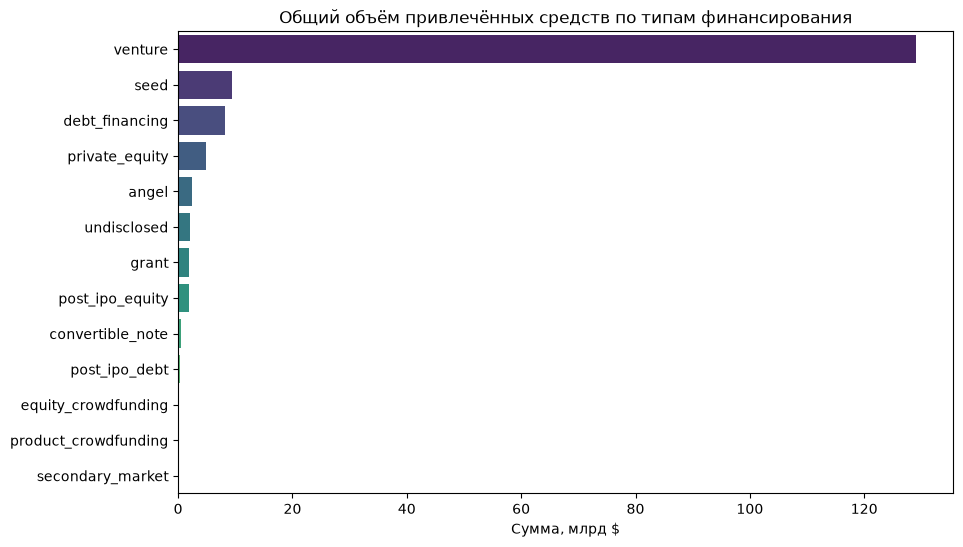

In [46]:
# Список столбцов с типами финансирования
funding_columns = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Считаем общую сумму по каждому типу финансирования
funding_summary = (
    investments_clean[funding_columns]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Переименовываем столбцы
funding_summary.columns = ['Тип финансирования', 'Сумма']

# Переводим в миллиарды долларов
funding_summary['Сумма'] = funding_summary['Сумма'] / 1e9

# График
plt.figure(figsize=(10,6))

sns.barplot(
    data=funding_summary,
    x='Сумма',
    y='Тип финансирования',
    hue='Тип финансирования',
    palette='viridis',
    legend=False
)

plt.title('Общий объём привлечённых средств по типам финансирования')
plt.xlabel('Сумма, млрд $')
plt.ylabel('')
plt.show()

Финансирование типа `venture` является абсолютным лидером по суммарному объёму привлечённых средств. Это свидетельствует о том, что данный механизм является основным источником финансирования стартапов на рассматриваемом рынке.

Также построим график, который покажет популярность разных типов финансирования, которые встречаются в датасете наибольшее количество раз. То есть какие типы финансирования чаще всего используются компаниями

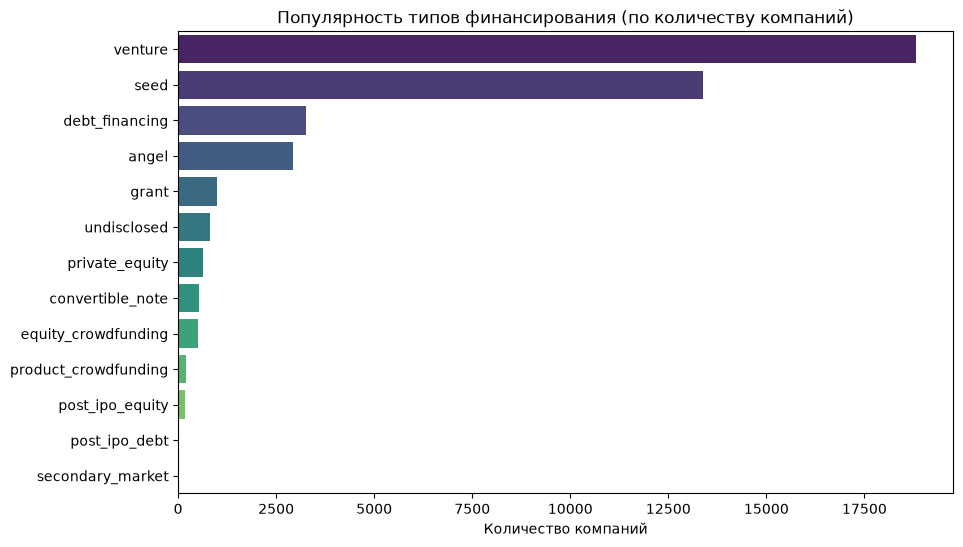

In [47]:
# Список столбцов с типами финансирования
funding_columns = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Считаем, сколько раз каждый тип финансирования встречается (значение > 0)
funding_popularity = (
    (investments_clean[funding_columns] > 0)
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Переименовываем столбцы
funding_popularity.columns = ['Тип финансирования', 'Количество компаний']

funding_popularity
# График популярности типов финансирования
plt.figure(figsize=(10, 6))
# Строим график столбчатой диаграммы
sns.barplot(
    data=funding_popularity,
    x='Количество компаний',
    y='Тип финансирования',
    hue='Тип финансирования',
    palette='viridis',
    legend=False
)
# Оформляем внешний вид
plt.title('Популярность типов финансирования (по количеству компаний)')
plt.xlabel('Количество компаний')
plt.ylabel('')
plt.show()

Некоторые типы финансирования используются значительно чаще остальных, однако высокая популярность далеко не всегда сопровождается крупными объёмами инвестиций.

Сравнение графиков показывает, что наиболее популярные типы финансирования не всегда обеспечивают наибольший объём инвестиций. Некоторые инструменты используются относительно редко, однако характеризуются значительно более крупными суммами финансирования на одну сделку.
Сравнивая оба графика, можно увидеть закономерность:
- Часто используются, но объём небольшой:
    - `seed` — 2-е место по популярности, но по сумме лишь на 3-м месте — суммы на посевной стадии массовые, но небольшие.
    - `angel` — 4-е место по популярности, но по сумме — почти в самом низу.
    - `grant` — тоже относительно часто встречается, но суммарный объём мал.

- Используются редко, но объём значительный (мало компаний, много денег):
    - `private_equity` — по количеству компаний лишь на 7-м месте, но по сумме — на 4-м месте — то есть каждая отдельная сделка крупная.
    - `post_ipo_equity` — используется совсем редко, но занимает 5-е место по сумме.
    - `post_ipo_debt` — почти не встречается (близко к нулю по количеству), но при этом даёт ~4 млрд $ суммарно — то есть единичные, но очень крупные сделки.

Вывод: ранние стадии финансирования (seed, angel, grant) — массовые, но с небольшими чеками; поздние/институциональные стадии (private_equity, post_ipo_equity, post_ipo_debt) — редкие, но с крупными суммами за сделку. Это логично: чем позже стадия компании, тем меньше таких компаний остаётся "в живых", но тем крупнее становятся вложения в них.

Постром график суммарных объёмов возвратов от разных типов финансирования за весь период

In [48]:
# Список столбцов с типами финансирования в returns_df
returns_columns = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding']

# Считаем сумму по каждому столбцу (по всем годам, так как year — это индекс)
total_returns = returns_df[returns_columns].sum().sort_values(ascending=False).reset_index()
total_returns.columns = ['Тип финансирования', 'Суммарный возврат']

total_returns

,Тип финансирования,Суммарный возврат
0,venture,40578.62
1,debt_financing,4734.85
2,private_equity,3587.33
3,seed,2382.24
4,angel,1509.23
5,post_ipo_equity,1104.96
6,undisclosed,730.88
7,post_ipo_debt,91.03
8,convertible_note,34.79
9,secondary_market,5.20


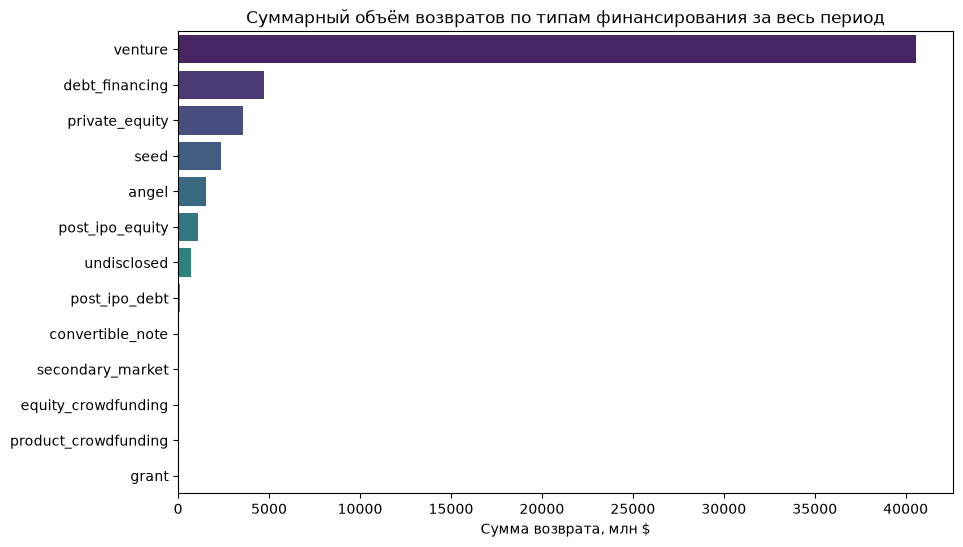

In [49]:
# Создаем фигуру графика
plt.figure(figsize=(10, 6))
# Сторим график
sns.barplot(
    data=total_returns,
    x='Суммарный возврат',
    y='Тип финансирования',
    hue='Тип финансирования',
    palette='viridis',
    legend=False
)
# Добавляем заголовок и подписи осей
plt.title('Суммарный объём возвратов по типам финансирования за весь период')
plt.xlabel('Сумма возврата, млн $')
plt.ylabel('')
# Выводим график
plt.show()

Абсолютный лидер по возвратам — `venture` (~40 млрд $), с большим отрывом от всех остальных. Дальше идут `debt_financing, private_equity и seed.` Такие типы, как `grant, product_crowdfunding, equity_crowdfunding и secondary_market `— почти нулевой возврат (что логично: гранты обычно безвозмездны, а по краудфандингу возврат вообще не предполагается в классическом понимании).
Наибольший объём возвратов демонстрируют те же типы финансирования, которые лидируют по объёму привлечённых инвестиций. Это ожидаемо, поскольку больший объём вложений потенциально приводит и к большему объёму возвращённых средств.

- venture — лидирует и по объёму вложений, и по возврату — самый весомый и надёжный по деньгам тип финансирования.
- seed — был очень популярен по количеству компаний, но и по вложениям, и по возврату занимает лишь среднюю позицию — то есть много мелких сделок, скромная отдача.
- debt_financing и private_equity — не самые популярные по количеству, но стабильно показывают solid возврат, подтверждая более раннее наблюдение о "редких, но крупных" типах.

На данном этапе были выявлены и исключены аномальные наблюдения, после чего проведён анализ различных типов финансирования. Полученные результаты показывают существенные различия как в объёмах инвестиций, так и в популярности отдельных инструментов финансирования, что важно учитывать при дальнейшем анализе динамики рынка.

## 5. Анализ динамики
### 5.1. Динамика предоставления финансирования по годам


Создадим новый столбец — средний размер одного раунда для каждой компании.

In [50]:
# Новый столбец со средним размером одного раунда avg_round_size
investments_clean['avg_round_size'] = investments_clean['funding_total_usd'] /investments_clean['funding_rounds']

In [51]:
# Извлекаем год финансирования из mid_funding_at для дальнейшей группировки.
investments_clean['funding_year'] = investments_clean['mid_funding_at'].dt.year

In [52]:
# Рассчитываем средний размер раунда на каждый год
avg_round_by_year = (
    investments_clean
    .groupby('funding_year')['avg_round_size']
    .mean()
    .reset_index()
)

avg_round_by_year

,funding_year,avg_round_size
0,2000,4.492723e+06
1,2001,3.366817e+06
2,2002,4.053461e+06
3,2003,3.099490e+06
4,2004,4.616702e+06
5,2005,5.801089e+06
6,2006,5.346925e+06
7,2007,4.678782e+06
8,2008,4.322739e+06
9,2009,3.517328e+06


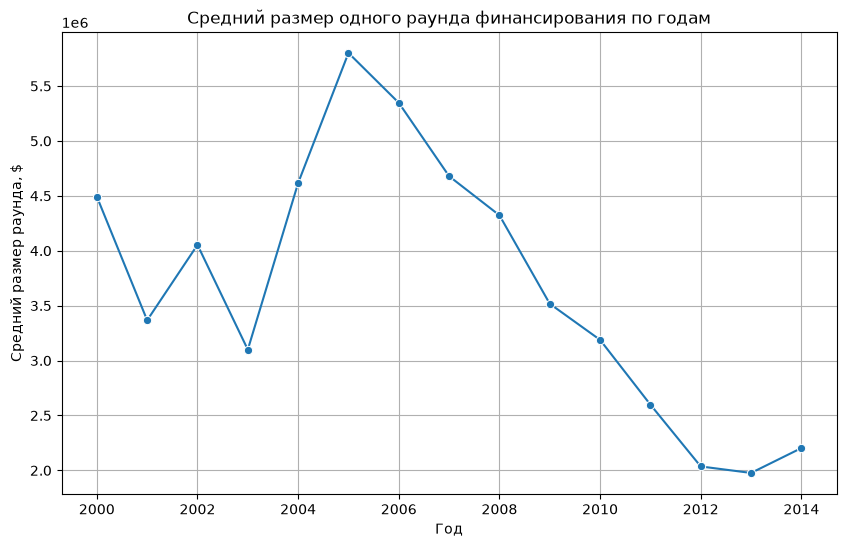

In [53]:
# Создаём фигуру графика
plt.figure(figsize=(10,6))
# Сторим линейный график
sns.lineplot(
    data=avg_round_by_year,
    x='funding_year',
    y='avg_round_size',
    marker='o'
)
# Настраиваем внешний вид графика и выводим его на экран
plt.title('Средний размер одного раунда финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Средний размер раунда, $')

plt.grid(True)

plt.show()

Средний размер одного раунда финансирования менялся неравномерно. Максимальное значение наблюдалось в 2005 году и составило около 5,8 млн долларов. После этого показатель постепенно снижался. Наименьшее значение отмечено в 2013 году (около 2,2 млн долларов). В 2014 году после длительного снижения произошло увеличение среднего размера одного раунда примерно до 3,8 млн долларов.

Посчитаем динамику общего количества раундов за каждый год

In [54]:
# Расчитываем общее количество раундов за каждый год
rounds_by_year = (
    investments_clean
    .groupby('funding_year')['funding_rounds']
    .sum()
    .reset_index()
)

rounds_by_year

,funding_year,funding_rounds
0,2000,113.0
1,2001,66.0
2,2002,98.0
3,2003,125.0
4,2004,181.0
5,2005,948.0
6,2006,1849.0
7,2007,2842.0
8,2008,3663.0
9,2009,4617.0


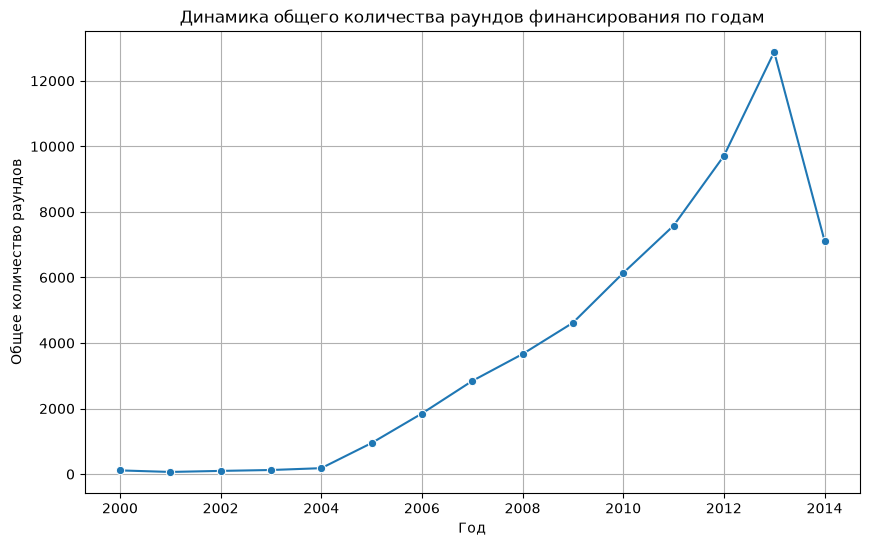

In [55]:
# Создаём фигуру графика
plt.figure(figsize=(10,6))
# Строим линейный график
sns.lineplot(
    data=rounds_by_year,
    x='funding_year',
    y='funding_rounds',
    marker='o'
)
# Настраиваем внешний вид графика и выводим его на экран
plt.title('Динамика общего количества раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Общее количество раундов')

plt.grid(True)

plt.show()

На основе данных можно сделать вывод что, максимальный типичный размер одного раунда финансирования наблюдался в 2005 году и составил около 5,8 млн долларов. После этого показатель постепенно снижался, что говорит об уменьшении среднего объема средств, привлекаемых в рамках одного раунда.
В 2014 году количество раундов финансирования значительно снизилось по сравнению с 2013 годом, однако средний размер одного раунда увеличился. Это означает, что сделок стало меньше, но каждая из них в среднем была крупнее.

### 5.2. Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. 

In [56]:
# Считаем суммарный объём финансирования (funding_total_usd) по каждому сегменту рынка (market) в разбивке по годам (funding_year)
market_year = (
    investments_clean
    .groupby(['market', 'funding_year'])['funding_total_usd']
    .sum()
    .reset_index()
)

In [57]:

# Разворачиваем таблицу в сводный формат (pivot):
market_pivot = market_year.pivot(
    index='market',              # строки — сегменты рынка,
    columns='funding_year',      # столбцы — годы,
    values='funding_total_usd'   # значения — суммарное финансирование
).fillna(0)                       # Пропуски (сегмент не получал финансирование в этот год) заполняем нулями


In [58]:
# средние и нишевые исключаем, чтобы рассматривать толбко массовые сегменты
market_pivot = market_pivot.drop(
    index=['mid', 'niche','unknown'],
    errors='ignore'
)

In [59]:
# Найдём сегменты, которые показали рост суммарного финансирования в 2014 году по сравнению с 2013 годом
growing_markets = market_pivot[
    market_pivot[2014] > market_pivot[2013]
].index

growing_markets

Index(['Apps', 'Big Data', 'Design', 'Internet', 'Manufacturing', 'Medical',
       'Real Estate', 'SaaS', 'Startups', 'Technology'],
      dtype='str', name='market')

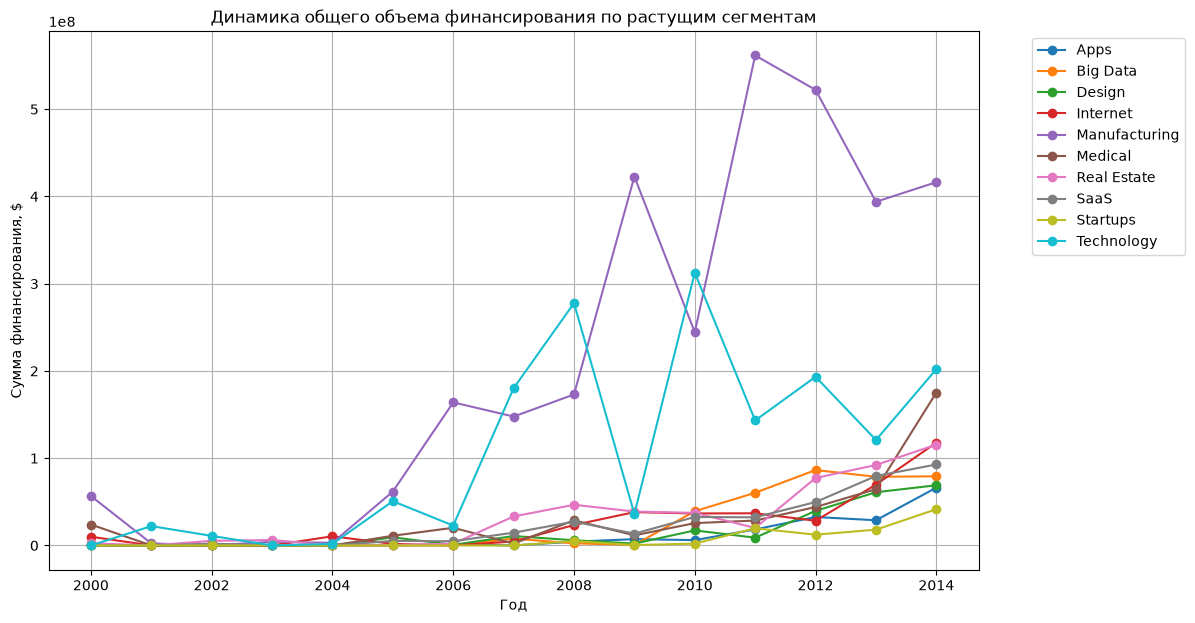

In [60]:
# Отбираем данные только по растущим сегментам (growing_markets) 
plot_data = market_pivot.loc[growing_markets].T

# Создаём фигуру графика
plt.figure(figsize=(12,7))

# Для каждого сегмента (столбца) строим отдельную линию на графике
for column in plot_data.columns:
    plt.plot(
        plot_data.index,      # ось X — годы
        plot_data[column],    # ось Y — сумма финансирования этого сегмента
        marker='o',           # отмечаем точками каждый год на линии
        label=column          # подпись линии — название сегмента (для легенды)
    )

# Настраиваем внешний вид графика и выводим его на экран   
plt.title('Динамика общего объема финансирования по растущим сегментам')
plt.xlabel('Год')
plt.ylabel('Сумма финансирования, $')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.show()


Наибольший объем финансирования среди растущих сегментов рынка наблюдается в категории Manufacturing, для которой характерны значительные колебания по годам.Также наблюдается значительные колебания у сегмента Technology. Устойчивый рост также демонстрируют сегменты Medical, Internet и Real Estate. Остальные сегменты увеличивают объем финансирования более плавно и остаются значительно ниже лидеров. В анализ были включены только сегменты, в которых суммарный объем финансирования в 2014 году оказался выше, чем в 2013 году. Наиболее заметный рост наблюдается у отдельных сегментов, тогда как остальные демонстрируют более умеренное увеличение объема привлеченных инвестиций.

### 5.3 Годовая динамика доли возвращённых средств по типам финансирования

Чтобы узнать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам, нужно для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств

In [61]:
# Считаем сумму финансирования по годам, но только по нужным типам:
# venture, debt_financing, private_equity, seed, angel
funding_by_year = (
    investments_clean
    .groupby('funding_year')[
        ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
    ]
    .sum()
    .reset_index()
)
# Выводим первые строки на экран
funding_by_year.head()

,funding_year,venture,debt_financing,private_equity,seed,angel
0,2000,327962152.0,14000000.0,0.0,16759140.0,24086333.0
1,2001,217519117.0,5829217.0,0.0,2667675.0,1000000.0
2,2002,306940622.0,15309671.0,7500000.0,10465192.0,3000000.0
3,2003,372234425.0,1050000.0,0.0,15318355.0,5629661.0
4,2004,664150451.0,30816623.0,0.0,18104728.0,11013741.0


In [62]:
# Объединяем таблицу возвратов (returns_df) с суммами финансирования по годам,
# сопоставляя год возврата (year) с годом финансирования (funding_year)
returns_merge = returns_df.merge(
    funding_by_year,
    left_on='year',
    right_on='funding_year',
    how='left'
)

returns_merge.head()

,seed_x,venture_x,equity_crowdfunding,undisclosed,convertible_note,debt_financing_x,angel_x,grant,private_equity_x,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,funding_year,venture_y,debt_financing_y,private_equity_y,seed_y,angel_y
0,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0,2000,327962152.0,14000000.0,0.0,16759140.0,24086333.0
1,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0,2001,217519117.0,5829217.0,0.0,2667675.0,1000000.0
2,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0,2002,306940622.0,15309671.0,7500000.0,10465192.0,3000000.0
3,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0,2003,372234425.0,1050000.0,0.0,15318355.0,5629661.0
4,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0,2004,664150451.0,30816623.0,0.0,18104728.0,11013741.0


In [63]:
for col in ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']: returns_merge[col + '_x'] *= 1_000_000.

после объединения Pandas автоматически добавил суффиксы _x и _y.

- _x — значения из returns_df (возвраты);
- _y — значения из funding_by_year (финансирование).

Поэтому:

In [64]:
eps = 1e-60

for col in ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']:
    returns_merge[col + '_share'] = (
        returns_merge[col + '_x'] /
        (returns_merge[col + '_y'] + eps)
    )

In [65]:
# Заменяем слишком большие значения на пропуски
for col in ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']:
    returns_merge.loc[
        returns_merge[col + '_share'] > 1,
        col + '_share'
    ] = np.nan

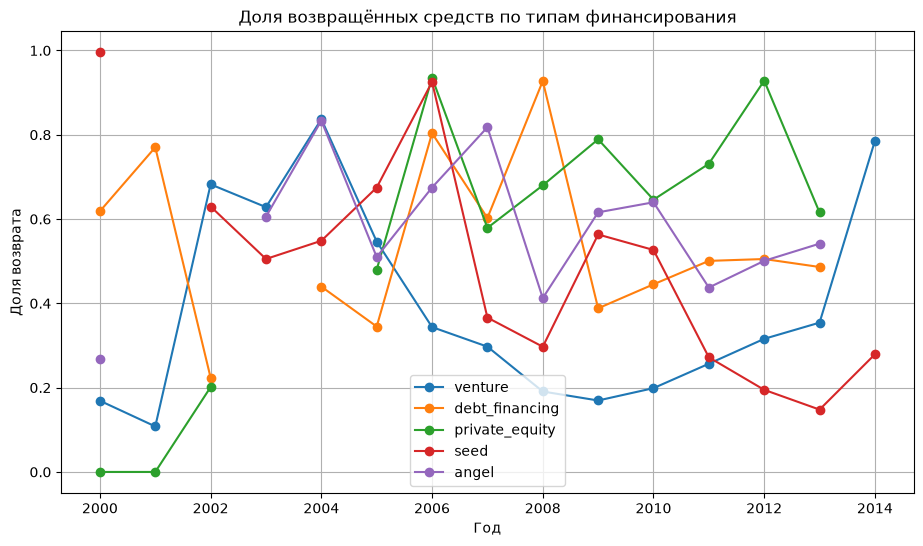

In [66]:
# Сроим график
plt.figure(figsize=(11,6))

for col in ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']:
   plt.plot(
    returns_merge['funding_year'],
    returns_merge[col + '_share'],
    marker='o',
    label=col
)

plt.title('Доля возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата')
plt.grid(True)
plt.legend()

plt.show()

График показывает, что доля возвращённых средств различается в зависимости от типа финансирования и года. Наиболее устойчивую динамику демонстрирует `private_equity`: после 2006 года показатель остаётся сравнительно высоким и в отдельные годы достигает максимальных значений. Для `venture`, `seed`, `angel` и `debt_financing` характерны более выраженные колебания, что свидетельствует о менее стабильной эффективности возврата инвестиций.

Анализ годовой динамики показал, что эффективность возврата инвестиций существенно зависит от типа финансирования. Наиболее стабильный рост доли возвратов наблюдается у private_equity, тогда как остальные типы характеризуются значительными колебаниями по годам. Полученные результаты позволяют сделать вывод, что при оценке эффективности инвестиций важно учитывать не только объём привлечённых средств, но и тип финансирования, поскольку именно он оказывает заметное влияние на вероятность возврата вложений.

## 6. Итоговый вывод и рекомендации

- Рекомендуемый сегмент рынка: `Manufacturing`, поскольку он демонстрировал устойчивый рост объёма финансирования в последние годы исследования и вошёл в число наиболее быстрорастущих сегментов.

- Предпочтительный тип финансирования: `venture`, так как он является лидером по суммарному объёму привлечённых инвестиций, широко используется компаниями и характеризуется высокими показателями возврата средств.

В ходе исследования были загружены и подготовлены данные: исправлены названия столбцов, обработаны пропуски и дубликаты, преобразованы типы данных, восстановлены значения mid_funding_at, сформированы новые признаки, исключены аномальные наблюдения и компании с недостаточным количеством раундов финансирования. После предобработки выполнен анализ структуры рынка, динамики инвестиций и эффективности различных типов финансирования.

Основные выводы исследования:

- около 59% компаний получили финансирование только один раз, однако основная часть инвестиций приходится на компании с более длительным периодом финансирования;
- рынок характеризуется высокой концентрацией нишевых сегментов;
- тип финансирования `venture` лидирует по объёму привлечённых инвестиций и популярности среди компаний;
- `private equity` демонстрирует наиболее стабильную динамику доли возврата средств;
- в 2014 году наиболее устойчивый рост финансирования показали сегменты `Technology, Medical, Internet и Manufacturing`.

Полученные результаты согласуются между собой: выбранный сегмент рынка демонстрирует положительную динамику развития, а рекомендуемый тип финансирования подтверждает свою эффективность по нескольким ключевым показателям анализа.

Рекомендация на 2015 год: инвестировать в сегмент `Manufacturing`, используя преимущественно `venture-финансирование`, поскольку именно это сочетание по результатам исследования выглядит наиболее перспективным с точки зрения объёма инвестиций, устойчивости рынка и потенциальной эффективности вложений.
